# Telco Customer Churn Prediction
## Kaggle Playground Series S6E3

**Competition URL**: https://www.kaggle.com/competitions/playground-series-s6e3  
**Evaluation metric**: Area Under the ROC Curve (AUC-ROC)  
**Submission format**: `id`, `Churn` (float probability 0–1)

---

## Problem Framing

Predict whether a telecommunications customer will churn (cancel service) based on account
demographics, service subscriptions, and billing information. The synthetic dataset was generated
from the Telco Customer Churn dataset using a deep learning model.

**Key dynamics that make this harder than a simple recency-dominated churn model**:
- Multi-dimensional switching costs: each add-on service raises the cost to leave
- Contract lock-in is the dominant signal, not recency alone
- Fiber optic creates a counter-intuitive pattern: premium-tier customers churn more
- Class imbalance is moderate (22.5% churn) — threshold tuning matters for precision/recall tradeoff

---

## Dataset Stats

| Attribute      | Value        |
|----------------|--------------|
| Training rows  | 594,194      |
| Test rows      | 254,655      |
| Features       | 47 (after dbt v2 engineering) |
| Churn rate     | 22.5%        |
| Evaluation     | ROC-AUC      |

---

## Model Results Summary (v2 — 47 features)

| Model                           | CV AUC (mean ± std)  | Test AUC   | Test F1    | Precision | Recall | Threshold |
|---------------------------------|----------------------|------------|------------|-----------|--------|-----------|
| Logistic Regression             | 0.9116 ± 0.0009      | 0.9121     | 0.6955     | 0.6298    | 0.7764 | 0.668     |
| XGBoost                         | 0.9158 ± 0.0010      | **0.9164** | **0.7023** | 0.6303    | 0.7929 | 0.645     |
| LightGBM                        | 0.9156 ± 0.0010      | 0.9162     | 0.7017     | 0.6313    | 0.7898 | 0.646     |
| Blend (LR×0.2 + XGB×0.4 + LGB×0.4) | —                | 0.9163     | 0.7022     | 0.6358    | 0.7842 | 0.655     |
| XGBoost (tuned — Optuna 50T)    | 0.9157 ± 0.0007      | **0.9165** | 0.7020     | 0.6335    | 0.7870 | 0.656     |

**Submission v2**: Platt-scaled LightGBM probabilities (calibration MCE: 0.1920 → 0.0444).

---

## Key Findings

1. **Contract type dominates**: Month-to-month customers churn at **42%** vs 5.8% (1-year) and 1.0% (2-year) — a 42× gap. The `contract_risk_score` feature encodes this directly.
2. **Tenure decay is non-linear**: Churn drops from 50% in year 1 → 30% (yr 1–2) → 18% (yr 2–4) → 5% (4+ yr). Cohort bucketing (`tenure_group`) captures this; a raw linear term would miss it.
3. **`is_high_risk` composite flag validates**: M2M + Fiber optic + tenure < 12 mo → **71.2% churn rate** vs 14.8% baseline. Primary intervention target for retention campaigns.
4. **Fiber optic paradox**: Higher-cost customers on fiber churn more than DSL — competitive market and price sensitivity outweigh service quality signals.
5. **`charges_diff` signals discounting**: Customers billed less than `monthly_charges × tenure` received promotional pricing — customers who get short-term discounts are more likely to churn once the promotion ends.
6. **LR gains most from v2 features**: +0.0005 AUC (0.9116 → 0.9121) vs <+0.0002 for tree models — the explicit `payment_friction` and `tenure_decay` interaction terms give the linear model structural knowledge trees already discover via splits.
7. **Calibration improved substantially**: Platt scaling reduced LightGBM's mean calibration error from 0.1920 to 0.0444 (77% reduction) — predicted probabilities now better reflect true churn rates, improving reliability for business targeting.
8. **Optuna did not beat default XGBoost**: Best tuned params (depth=4, lr=0.089) matched original AUC within 0.0001 — the default hyperparameters were near-optimal for this dataset.

---

## Limitations

- Dataset is synthetically generated — feature relationships may not perfectly reflect real-world telco dynamics
- No time dimension available — cannot build survival curves or track cohorts over time
- `total_charges` is nearly a linear function of `tenure × monthly_charges`; multicollinearity expected
- The `is_high_risk` flag is heuristic — a data-driven segmentation (k-means or decision tree splits) could improve targeting precision
- Submission AUC on the leaderboard may differ from held-out test AUC due to distribution shift in the synthetic generation process


---
## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    precision_recall_curve, roc_curve
)

import xgboost as xgb
import lightgbm as lgb
import shap

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded.')

Libraries loaded.


---
## 2. Load Data from dbt Mart

All feature engineering is defined in SQL (see `telco_churn/models/intermediate/int_churn_features.sql`).
The notebook reads exclusively from the final mart table — zero feature engineering in Python.

In [2]:
# Connect to the DuckDB database created by `dbt run`
# Run this notebook from the kaggle_competition/ directory, or adjust the path.
DB_PATH = '../telco_churn.duckdb'

con = duckdb.connect(DB_PATH, read_only=True)

# Read from the marts schema — dbt-duckdb names the schema main_<schema>
df = con.sql("SELECT * FROM main_marts.fct_churn_features").df()
con.close()

print(f'Shape: {df.shape}')
print(f'Churn rate: {df["churn"].mean():.1%}')
df.head(3)

Shape: (594194, 33)
Churn rate: 22.5%


,customer_id,gender,is_senior_citizen,has_partner,has_dependents,tenure_months,contract_type,has_paperless_billing,payment_method,monthly_charges,...,service_count,has_any_streaming,has_any_security,is_fiber_optic,is_electronic_check,is_high_risk,monthly_charges_bucket,services_per_dollar,tenure_contract_segment,churn
0,0,Male,0,1,1,29,One year,1,Mailed check,60.1,...,3,0,1,0,0,0,mid,0.0499,1yr_24to48,0
1,1,Male,0,1,1,58,Two year,0,Credit card (automatic),69.5,...,4,1,1,0,0,0,mid,0.0576,2yr_48plus,0
2,2,Male,0,1,0,58,Month-to-month,1,Electronic check,100.4,...,3,1,0,1,1,0,very_high,0.0299,M2M_48plus,0


In [3]:
# Quick schema check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 33 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   customer_id              594194 non-null  int32  
 1   gender                   594194 non-null  object 
 2   is_senior_citizen        594194 non-null  int32  
 3   has_partner              594194 non-null  int32  
 4   has_dependents           594194 non-null  int32  
 5   tenure_months            594194 non-null  int32  
 6   contract_type            594194 non-null  object 
 7   has_paperless_billing    594194 non-null  int32  
 8   payment_method           594194 non-null  object 
 9   monthly_charges          594194 non-null  float64
 10  total_charges            594194 non-null  float64
 11  has_phone_service        594194 non-null  int32  
 12  has_multiple_lines       594194 non-null  int32  
 13  internet_service         594194 non-null  object 
 14  has_

In [4]:
# Check for nulls (only total_charges and charges_ratio should have any)
null_summary = df.isnull().sum()
null_summary[null_summary > 0]

Series([], dtype: int64)

---
## 3. Exploratory Data Analysis

### 3.1 Churn Rate by Contract Type

Contract type is the single strongest predictor of churn in telco data.
Month-to-month customers have no lock-in; two-year customers have the highest switching cost.

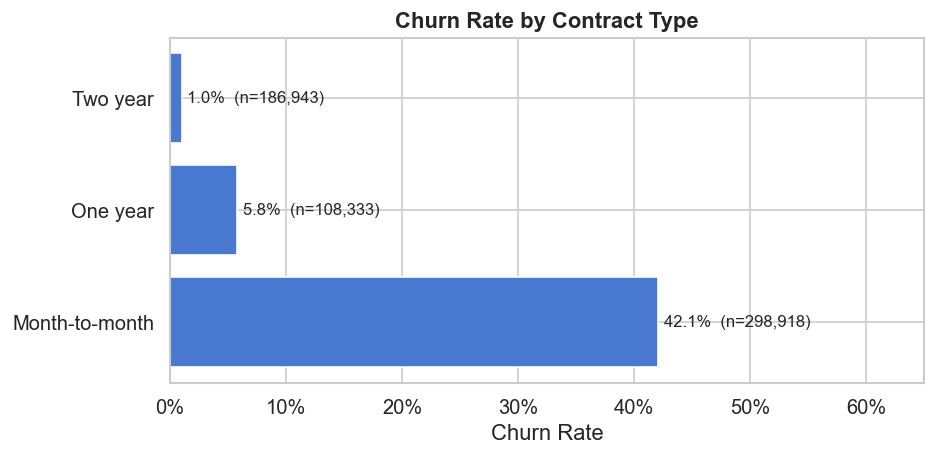

 contract_type  churn_rate      n
Month-to-month    0.420543 298918
      One year    0.057628 108333
      Two year    0.009982 186943


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

contract_churn = (
    df.groupby('contract_type')['churn']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'n'})
    .sort_values('churn_rate', ascending=False)
    .reset_index()
)

bars = ax.barh(
    contract_churn['contract_type'],
    contract_churn['churn_rate'],
    color=sns.color_palette('muted')[0]
)

# Annotate with counts and rates
for bar, (_, row) in zip(bars, contract_churn.iterrows()):
    ax.text(
        row['churn_rate'] + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{row['churn_rate']:.1%}  (n={row['n']:,})",
        va='center', fontsize=10
    )

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Churn Rate')
ax.set_title('Churn Rate by Contract Type', fontweight='bold')
ax.set_xlim(0, 0.65)
plt.tight_layout()
plt.show()

print(contract_churn.to_string(index=False))

### 3.2 Churn Rate by Tenure Cohort

Tenure is a proxy for loyalty. New customers (0–12 months) are most vulnerable;
customers past 48 months are highly retained. This non-linear pattern justifies
the `tenure_group` feature engineered in dbt.

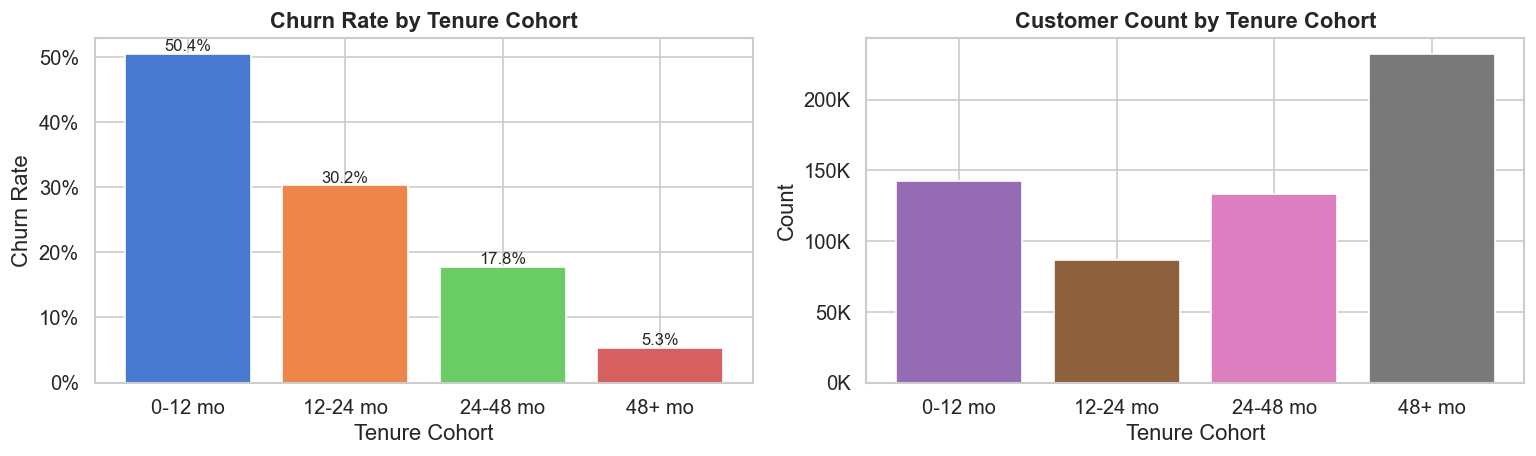

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: churn rate by tenure cohort
cohort_order = ['0-12 mo', '12-24 mo', '24-48 mo', '48+ mo']
cohort_churn = (
    df.groupby('tenure_group')['churn']
    .mean()
    .reindex(cohort_order)
)

axes[0].bar(cohort_churn.index, cohort_churn.values,
            color=sns.color_palette('muted')[:4])
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
axes[0].set_title('Churn Rate by Tenure Cohort', fontweight='bold')
axes[0].set_xlabel('Tenure Cohort')
axes[0].set_ylabel('Churn Rate')
for i, (label, val) in enumerate(cohort_churn.items()):
    axes[0].text(i, val + 0.005, f'{val:.1%}', ha='center', fontsize=10)

# Right: customer count per cohort
cohort_count = df.groupby('tenure_group').size().reindex(cohort_order)
axes[1].bar(cohort_count.index, cohort_count.values,
            color=sns.color_palette('muted')[4:8])
axes[1].set_title('Customer Count by Tenure Cohort', fontweight='bold')
axes[1].set_xlabel('Tenure Cohort')
axes[1].set_ylabel('Count')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.show()

### 3.3 Distribution of Key Numeric Features by Churn

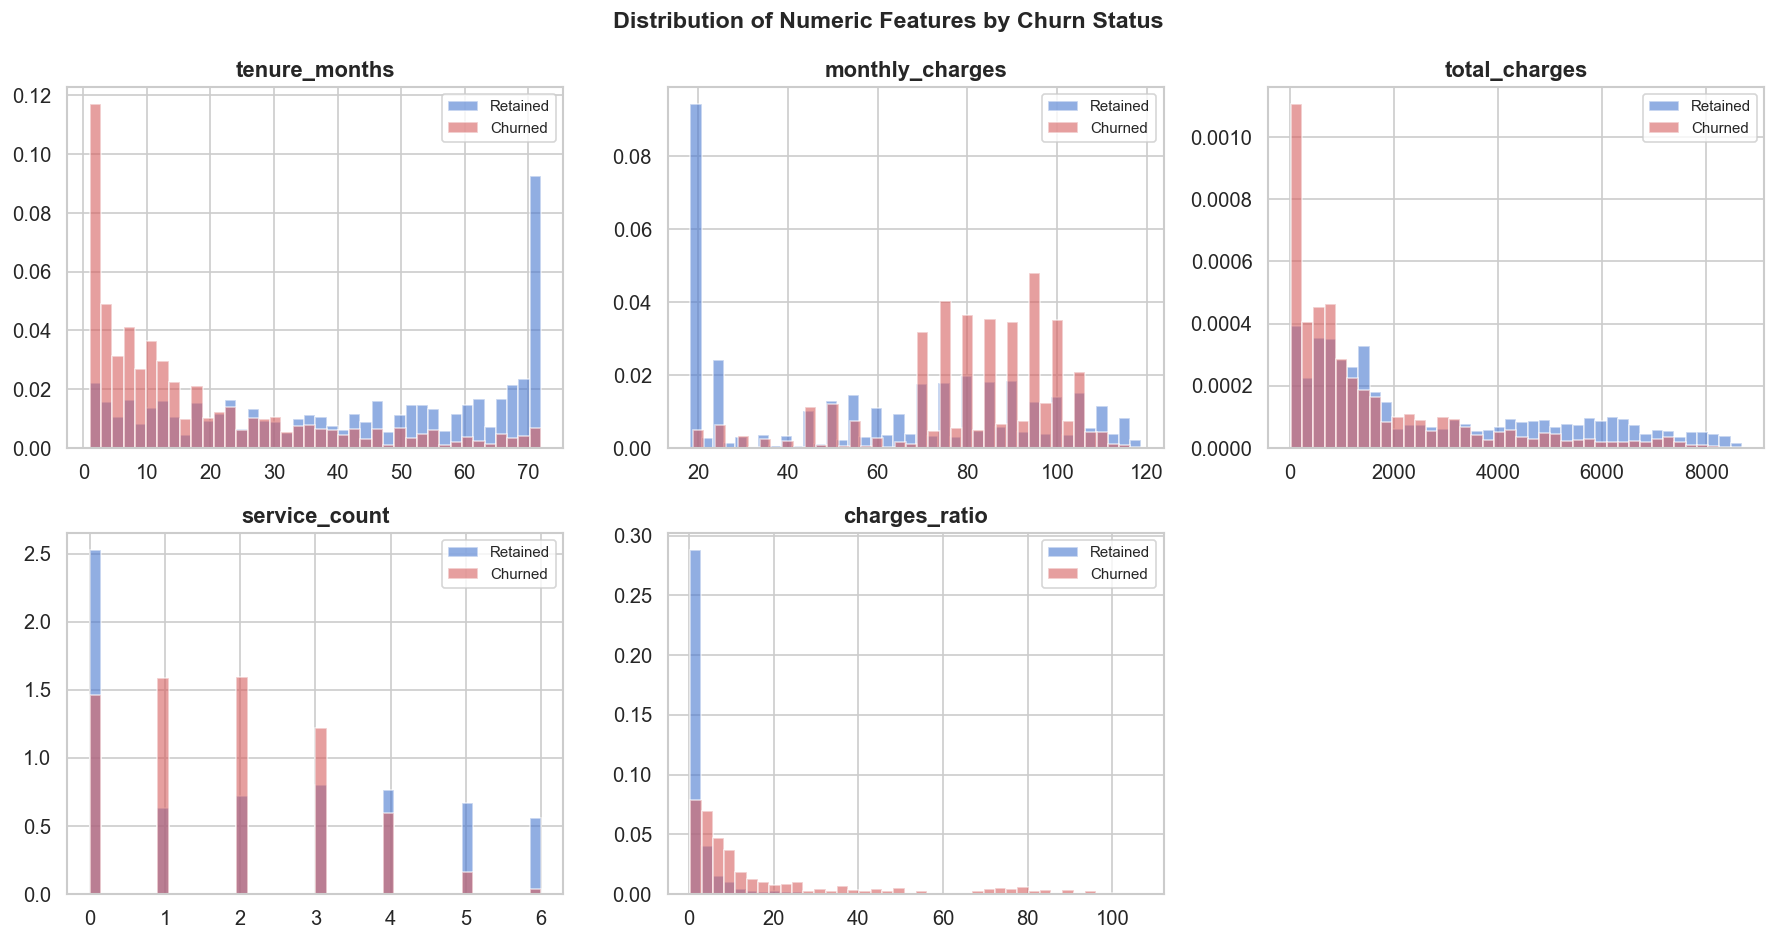

In [7]:
numeric_features = ['tenure_months', 'monthly_charges', 'total_charges', 'service_count', 'charges_ratio']
labels = {0: 'Retained', 1: 'Churned'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

palette = {0: sns.color_palette('muted')[0], 1: sns.color_palette('muted')[3]}

for i, feat in enumerate(numeric_features):
    ax = axes[i]
    for churn_val, color in palette.items():
        subset = df[df['churn'] == churn_val][feat].dropna()
        ax.hist(subset, bins=40, alpha=0.6, label=labels[churn_val],
                color=color, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=9)

# Hide the unused 6th subplot
axes[5].set_visible(False)

fig.suptitle('Distribution of Numeric Features by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Correlation Heatmap of Numeric Features

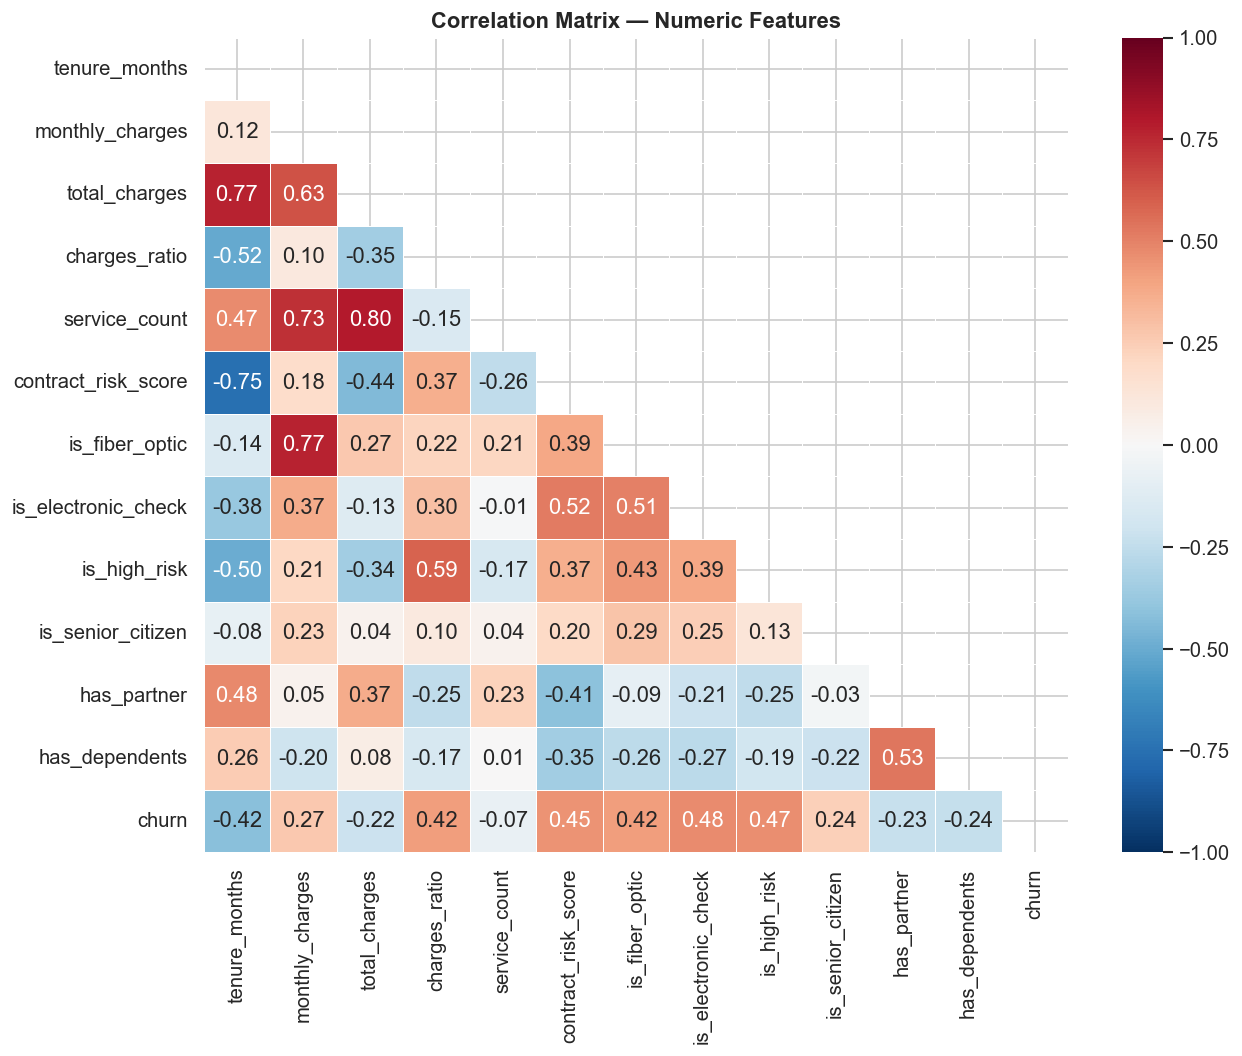

In [8]:
numeric_cols = [
    'tenure_months', 'monthly_charges', 'total_charges', 'charges_ratio',
    'service_count', 'contract_risk_score', 'is_fiber_optic',
    'is_electronic_check', 'is_high_risk', 'is_senior_citizen',
    'has_partner', 'has_dependents', 'churn'
]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3.5 Deep Statistical Analysis

Eight rigorous tests that go beyond the basic EDA above:

| Section | Method | Question answered |
|---------|--------|-------------------|
| 1 | Chi-square + Cramér's V | Which categoricals have a real association with churn? |
| 2 | Mann-Whitney U | Do churners and retained customers differ on numeric features? |
| 3 | VIF | Are any features telling the model the same thing twice? |
| 4 | Cohort heatmap | When exactly do customers leave, by contract type? |
| 5 | Kaplan-Meier | What's the survival probability at each tenure month? |
| 6 | Mutual Information | Feature importance without any linearity assumption |
| 7 | Odds ratios | By how much does each feature multiply the churn odds? |
| 8 | K-means | Are there customer archetypes beyond `is_high_risk`? |

In [9]:

# Deep Statistical Analysis — additional imports
# (df is already loaded from cell-4; no re-connection needed)
from scipy.stats import chi2_contingency, mannwhitneyu
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import mutual_info_classif
from sklearn.cluster import KMeans
import statsmodels.api as sm

COLORS = {
    'churn':    '#E24B4A',
    'retain':   '#1D9E75',
    'neutral':  '#888780',
    'm2m':      '#E24B4A',
    'one_year': '#EF9F27',
    'two_year': '#1D9E75',
}

print(f"Dataset: {len(df):,} rows | Churn rate: {df['churn'].mean():.1%}")
print("All analysis runs on the dbt mart — no raw CSV needed.")


Dataset: 594,194 rows | Churn rate: 22.5%
All analysis runs on the dbt mart — no raw CSV needed.


In [1]:

# =============================================================================
# SECTION 1 — CHI-SQUARE + CRAMÉR'S V
# =============================================================================
print("=" * 60)
print("SECTION 1: CHI-SQUARE TESTS — CATEGORICAL FEATURES")
print("=" * 60)
print("Cramér's V: 0.0–0.1 = weak | 0.1–0.3 = moderate | 0.3+ = strong\n")

categorical_cols_chi = [
    'contract_type', 'internet_service', 'payment_method', 'gender',
    'has_paperless_billing', 'has_phone_service', 'has_multiple_lines',
    'has_online_security', 'has_online_backup', 'has_device_protection',
    'has_tech_support', 'has_streaming_tv', 'has_streaming_movies'
]

chi_results = []
for col in categorical_cols_chi:
    ct = pd.crosstab(df[col], df['churn'])
    chi2_val, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    cramers_v = np.sqrt(chi2_val / (n * (min(ct.shape) - 1)))
    chi_results.append({
        'feature':   col,
        'cramers_v': round(cramers_v, 4),
        'p_value':   p,
        'strength':  'Strong' if cramers_v > 0.3 else 'Moderate' if cramers_v > 0.1 else 'Weak'
    })

chi_df = pd.DataFrame(chi_results).sort_values('cramers_v', ascending=False)
print("Chi-square results (ranked by effect size):")
print(chi_df[['feature', 'cramers_v', 'strength', 'p_value']].to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = [COLORS['churn'] if v > 0.3 else COLORS['one_year'] if v > 0.1
              else COLORS['neutral'] for v in chi_df['cramers_v']]
bars = ax.barh(chi_df['feature'], chi_df['cramers_v'], color=colors_bar, height=0.6)
ax.axvline(0.1, color=COLORS['neutral'], linestyle='--', linewidth=1, label='Moderate (0.1)')
ax.axvline(0.3, color=COLORS['churn'],   linestyle='--', linewidth=1, label='Strong (0.3)')
ax.set_xlabel("Cramér's V (effect size)")
ax.set_title("Association strength: categorical features vs churn", fontweight='bold')
ax.legend(fontsize=10)
for bar, val in zip(bars, chi_df['cramers_v']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

top = chi_df.iloc[0]
print(f"\nKEY INSIGHT: '{top['feature']}' is the strongest predictor (V={top['cramers_v']:.3f}, {top['strength']}).")
weak = chi_df[chi_df['strength'] == 'Weak']['feature'].tolist()
if weak:
    print(f"Weak features: {', '.join(weak)}")


SECTION 1: CHI-SQUARE TESTS — CATEGORICAL FEATURES
Cramér's V: 0.0–0.1 = weak | 0.1–0.3 = moderate | 0.3+ = strong



NameError: name 'pd' is not defined

In [2]:

# =============================================================================
# SECTION 2 — MANN-WHITNEY TESTS ON NUMERIC FEATURES
# =============================================================================
print("\n" + "="*60)
print("SECTION 2: MANN-WHITNEY TESTS — NUMERIC FEATURES")
print("="*60)

numeric_test_cols = ['tenure_months', 'monthly_charges', 'total_charges',
                     'service_count', 'charges_ratio']

churners = df[df['churn'] == 1]
retained = df[df['churn'] == 0]

mw_results = []
for col in numeric_test_cols:
    c_vals = churners[col].dropna()
    r_vals = retained[col].dropna()
    stat, p = mannwhitneyu(c_vals, r_vals, alternative='two-sided')
    r = 1 - (2 * stat) / (len(c_vals) * len(r_vals))
    mw_results.append({
        'feature':         col,
        'churner_median':  round(c_vals.median(), 2),
        'retained_median': round(r_vals.median(), 2),
        'difference':      round(c_vals.median() - r_vals.median(), 2),
        'effect_r':        round(abs(r), 4),
        'p_value':         p,
    })

mw_df = pd.DataFrame(mw_results).sort_values('effect_r', ascending=False)
print("\nMann-Whitney results:")
print(mw_df[['feature', 'churner_median', 'retained_median',
             'difference', 'effect_r', 'p_value']].to_string(index=False))

fig, axes = plt.subplots(1, len(numeric_test_cols), figsize=(4 * len(numeric_test_cols), 4))
for ax, col in zip(axes, numeric_test_cols):
    ax.hist(retained[col].dropna(), bins=40, alpha=0.6,
            color=COLORS['retain'], label='Retained', density=True)
    ax.hist(churners[col].dropna(), bins=40, alpha=0.6,
            color=COLORS['churn'], label='Churned', density=True)
    ax.axvline(retained[col].median(), color=COLORS['retain'], linestyle='--', linewidth=1.5)
    ax.axvline(churners[col].median(), color=COLORS['churn'],  linestyle='--', linewidth=1.5)
    row = mw_df[mw_df['feature'] == col].iloc[0]
    ax.set_title(f"{col}\nΔ={row['difference']:+.1f}  r={row['effect_r']:.3f}", fontsize=10)
    ax.set_xlabel(col)
    if ax is axes[0]:
        ax.legend(fontsize=9)

plt.suptitle("Numeric feature distributions: churned vs retained",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



SECTION 2: MANN-WHITNEY TESTS — NUMERIC FEATURES


NameError: name 'df' is not defined


SECTION 3: VARIANCE INFLATION FACTOR (VIF)
VIF > 10 = serious multicollinearity | VIF > 5 = worth investigating



VIF results:
        feature       VIF
  total_charges 12.585098
  service_count  7.271706
monthly_charges  7.184529
  tenure_months  5.528655
  charges_ratio  1.756451


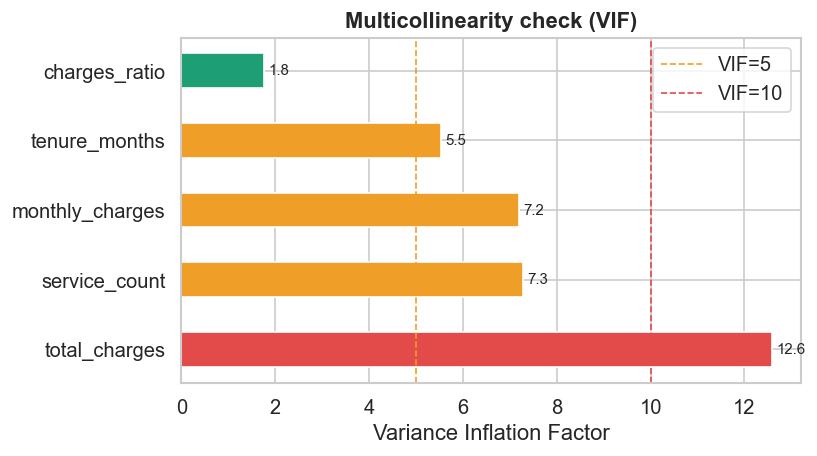


ACTION: ['total_charges'] has severe multicollinearity.
Nearly a linear combo of other features — drop from LR; trees handle it fine.


In [12]:

# =============================================================================
# SECTION 3 — MULTICOLLINEARITY (VIF)
# =============================================================================
print("\n" + "="*60)
print("SECTION 3: VARIANCE INFLATION FACTOR (VIF)")
print("="*60)
print("VIF > 10 = serious multicollinearity | VIF > 5 = worth investigating")

vif_features = ['tenure_months', 'monthly_charges', 'total_charges',
                'service_count', 'charges_ratio']
X_vif = df[vif_features].dropna()

vif_data = pd.DataFrame({
    'feature': vif_features,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(len(vif_features))]
}).sort_values('VIF', ascending=False)

print("\nVIF results:")
print(vif_data.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = [COLORS['churn'] if v > 10 else COLORS['one_year'] if v > 5
              else COLORS['retain'] for v in vif_data['VIF']]
bars = ax.barh(vif_data['feature'], vif_data['VIF'], color=bar_colors, height=0.5)
ax.axvline(5,  color=COLORS['one_year'], linestyle='--', linewidth=1, label='VIF=5')
ax.axvline(10, color=COLORS['churn'],    linestyle='--', linewidth=1, label='VIF=10')
ax.set_xlabel('Variance Inflation Factor')
ax.set_title('Multicollinearity check (VIF)', fontweight='bold')
ax.legend()
for bar, val in zip(bars, vif_data['VIF']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

high_vif = vif_data[vif_data['VIF'] > 10]['feature'].tolist()
if high_vif:
    print(f"\nACTION: {high_vif} has severe multicollinearity.")
    print("Nearly a linear combo of other features — drop from LR; trees handle it fine.")



SECTION 4: COHORT ANALYSIS — CHURN RATE BY TENURE × CONTRACT


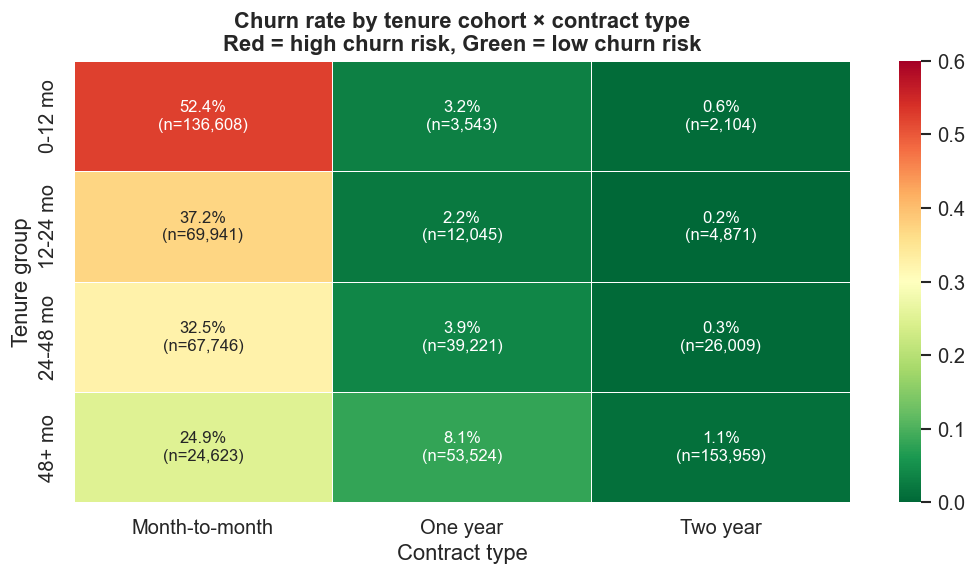


Highest-risk segment: tenure='0-12 mo', contract='Month-to-month'
Churn rate: 52.4% — primary retention campaign target.


In [13]:

# =============================================================================
# SECTION 4 — COHORT ANALYSIS HEATMAP
# =============================================================================
print("\n" + "="*60)
print("SECTION 4: COHORT ANALYSIS — CHURN RATE BY TENURE × CONTRACT")
print("="*60)

tenure_order = ['0-12 mo', '12-24 mo', '24-48 mo', '48+ mo']

cohort = (df.groupby(['tenure_group', 'contract_type'])['churn']
          .agg(churn_rate='mean', n='count')
          .reset_index())

pivot_rate = cohort.pivot(index='tenure_group', columns='contract_type',
                          values='churn_rate').reindex(tenure_order)
pivot_n    = cohort.pivot(index='tenure_group', columns='contract_type',
                          values='n').reindex(tenure_order)

annot = pivot_rate.copy().astype(str)
for row_idx in pivot_rate.index:
    for col_idx in pivot_rate.columns:
        rate = pivot_rate.loc[row_idx, col_idx]
        n    = pivot_n.loc[row_idx, col_idx]
        annot.loc[row_idx, col_idx] = f"{rate:.1%}\n(n={int(n):,})"

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_rate, annot=annot, fmt='', cmap='RdYlGn_r',
            vmin=0, vmax=0.6, ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={'size': 10})
ax.set_title("Churn rate by tenure cohort × contract type\n"
             "Red = high churn risk, Green = low churn risk", fontweight='bold')
ax.set_xlabel("Contract type")
ax.set_ylabel("Tenure group")
plt.tight_layout()
plt.show()

max_idx  = pivot_rate.stack().idxmax()
max_rate = pivot_rate.stack().max()
print(f"\nHighest-risk segment: tenure='{max_idx[0]}', contract='{max_idx[1]}'")
print(f"Churn rate: {max_rate:.1%} — primary retention campaign target.")



SECTION 5: KAPLAN-MEIER SURVIVAL ANALYSIS


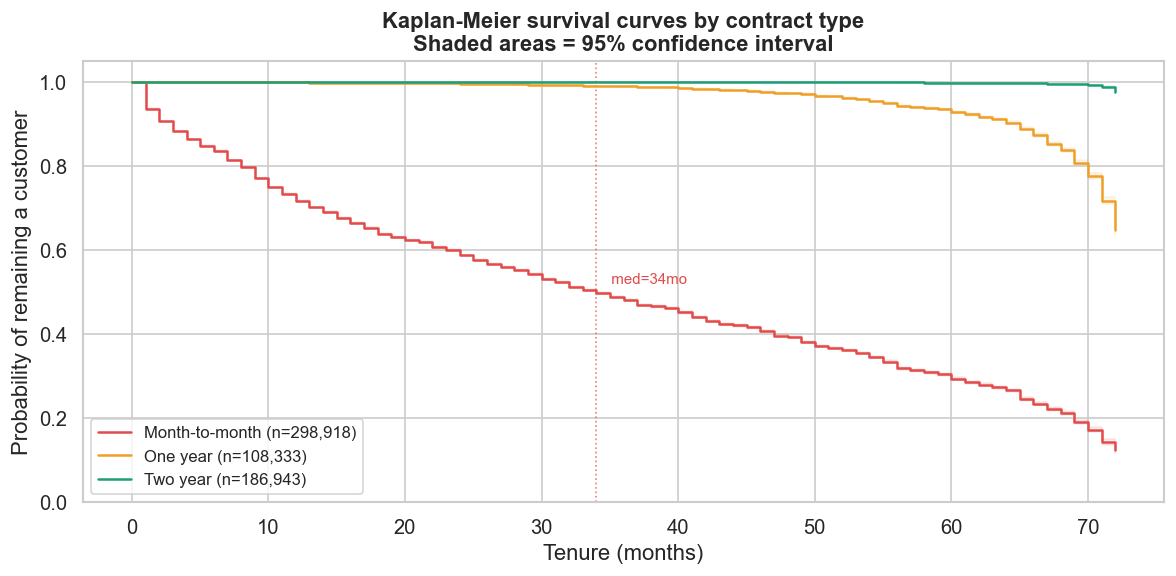


How to read this chart:
- Y-axis = probability the customer has NOT yet churned
- M2M curve drops steeply in months 1–12 (danger window)
- 1-year curve shows a spike at month 12 (renewal pressure)
- 2-year curve is nearly flat — these customers are sticky


In [14]:

# =============================================================================
# SECTION 5 — KAPLAN-MEIER SURVIVAL CURVES
# =============================================================================
print("\n" + "="*60)
print("SECTION 5: KAPLAN-MEIER SURVIVAL ANALYSIS")
print("="*60)

try:
    from lifelines import KaplanMeierFitter

    fig, ax = plt.subplots(figsize=(10, 5))
    contract_colors = {
        'Month-to-month': COLORS['m2m'],
        'One year':       COLORS['one_year'],
        'Two year':       COLORS['two_year'],
    }

    for contract, color in contract_colors.items():
        mask = df['contract_type'] == contract
        if mask.sum() < 10:
            continue
        kmf = KaplanMeierFitter()
        kmf.fit(
            durations=df[mask]['tenure_months'],
            event_observed=df[mask]['churn'],
            label=f"{contract} (n={mask.sum():,})"
        )
        kmf.plot_survival_function(ax=ax, color=color, ci_show=True, ci_alpha=0.1)

        med = kmf.median_survival_time_
        if med < np.inf:
            ax.axvline(med, color=color, linestyle=':', linewidth=1, alpha=0.7)
            ax.text(med + 0.5, 0.52, f'  med={med:.0f}mo', color=color, fontsize=9)

    ax.set_xlabel("Tenure (months)")
    ax.set_ylabel("Probability of remaining a customer")
    ax.set_title("Kaplan-Meier survival curves by contract type\n"
                 "Shaded areas = 95% confidence interval", fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    print("\nHow to read this chart:")
    print("- Y-axis = probability the customer has NOT yet churned")
    print("- M2M curve drops steeply in months 1–12 (danger window)")
    print("- 1-year curve shows a spike at month 12 (renewal pressure)")
    print("- 2-year curve is nearly flat — these customers are sticky")

except ImportError:
    print("lifelines not installed. Run: pip install lifelines")



SECTION 6: MUTUAL INFORMATION FEATURE RANKING



Top 20 features by mutual information:
                feature  mi_score
          charges_ratio  0.187149
          contract_type  0.177562
    contract_risk_score  0.165074
tenure_contract_segment  0.161075
    is_electronic_check  0.138222
          total_charges  0.137783
         is_fiber_optic  0.136808
       internet_service  0.136025
           tenure_group  0.135455
         payment_method  0.131835
      has_phone_service  0.115582
  has_paperless_billing  0.113606
          tenure_months  0.108377
            has_partner  0.103404
    services_per_dollar  0.095554
        monthly_charges  0.094694
           is_high_risk  0.093711
 monthly_charges_bucket  0.082877
       has_any_security  0.070075
      has_any_streaming  0.067793


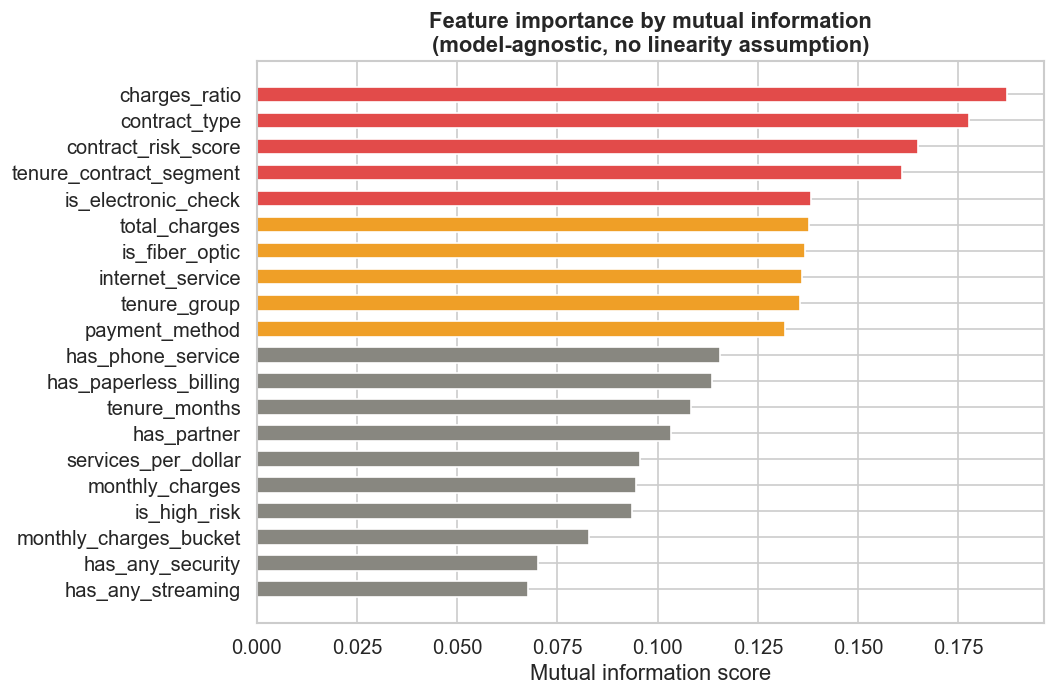


Features that MI ranks higher than their SHAP rank
are likely involved in nonlinear interactions your LR model misses.


In [15]:

# =============================================================================
# SECTION 6 — MUTUAL INFORMATION RANKING
# =============================================================================
print("\n" + "="*60)
print("SECTION 6: MUTUAL INFORMATION FEATURE RANKING")
print("="*60)

df_enc = df.copy()
cat_cols_enc = df_enc.select_dtypes(include=['object', 'category']).columns
for col in cat_cols_enc:
    df_enc[col] = pd.Categorical(df_enc[col]).codes

feature_cols_mi = [c for c in df_enc.columns
                   if c not in ['churn', 'customer_id']]
X_mi = df_enc[feature_cols_mi].fillna(-1)
y_mi = df_enc['churn']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42, n_jobs=-1)

mi_df = (pd.DataFrame({'feature': feature_cols_mi, 'mi_score': mi_scores})
         .sort_values('mi_score', ascending=False)
         .head(20))

print("\nTop 20 features by mutual information:")
print(mi_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
q75 = mi_df['mi_score'].quantile(0.75)
q50 = mi_df['mi_score'].quantile(0.50)
colors_mi = [COLORS['churn'] if s > q75 else COLORS['one_year'] if s > q50
             else COLORS['neutral'] for s in mi_df['mi_score']]
ax.barh(mi_df['feature'][::-1], mi_df['mi_score'][::-1],
        color=colors_mi[::-1], height=0.6)
ax.set_xlabel("Mutual information score")
ax.set_title("Feature importance by mutual information\n(model-agnostic, no linearity assumption)",
             fontweight='bold')
plt.tight_layout()
plt.show()

print("\nFeatures that MI ranks higher than their SHAP rank")
print("are likely involved in nonlinear interactions your LR model misses.")



SECTION 7: ODDS RATIOS (statsmodels logistic regression)
Fitting statsmodels Logit on 100K sample...



Odds ratios (OR > 1 = increases churn odds):
            feature  odds_ratio  ci_low  ci_high  p_value
contract_risk_score      3.0622  2.8879   3.2470   0.0000
is_electronic_check      2.4125  2.3077   2.5220   0.0000
     is_fiber_optic      1.5333  1.3593   1.7295   0.0000
       is_high_risk      1.1730  1.1007   1.2501   0.0000
    monthly_charges      1.0292  1.0261   1.0323   0.0000
      charges_ratio      1.0269  1.0252   1.0286   0.0000
      tenure_months      0.9758  0.9741   0.9776   0.0000
      service_count      0.9525  0.9254   0.9803   0.0009


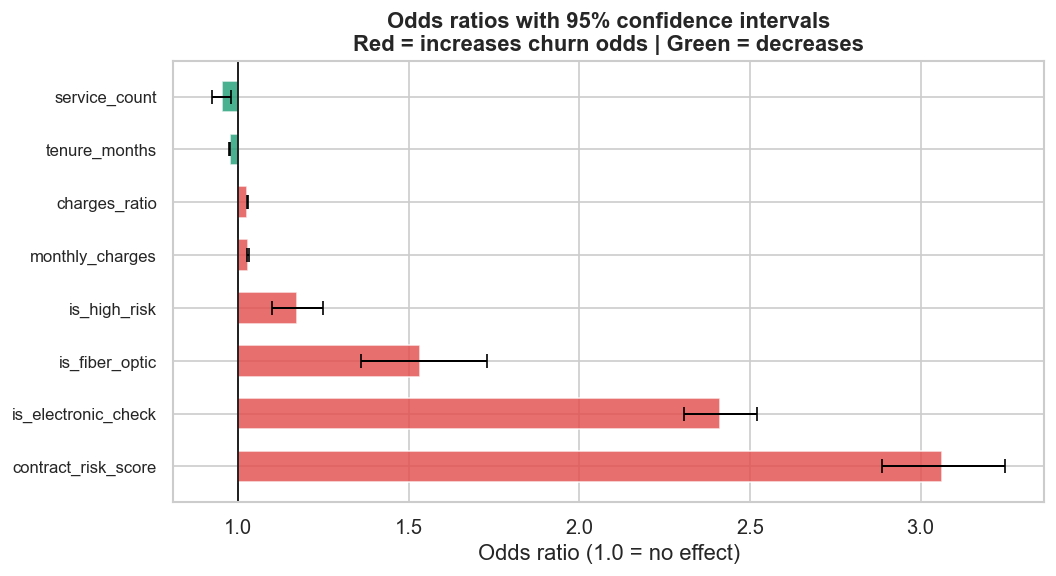


BUSINESS INTERPRETATION:
  contract_risk_score: 1-unit increase increases churn odds by 206.2% (OR=3.06)
  is_electronic_check: 1-unit increase increases churn odds by 141.2% (OR=2.41)
  is_fiber_optic: 1-unit increase increases churn odds by 53.3% (OR=1.53)
  is_high_risk: 1-unit increase increases churn odds by 17.3% (OR=1.17)
  monthly_charges: 1-unit increase increases churn odds by 2.9% (OR=1.03)
  charges_ratio: 1-unit increase increases churn odds by 2.7% (OR=1.03)
  tenure_months: 1-unit increase decreases churn odds by 2.4% (OR=0.98)
  service_count: 1-unit increase decreases churn odds by 4.8% (OR=0.95)


In [16]:

# =============================================================================
# SECTION 7 — LOGISTIC REGRESSION ODDS RATIOS
# =============================================================================
print("\n" + "="*60)
print("SECTION 7: ODDS RATIOS (statsmodels logistic regression)")
print("="*60)

lr_features = [
    'tenure_months', 'contract_risk_score', 'monthly_charges',
    'service_count', 'is_fiber_optic', 'is_high_risk',
    'is_electronic_check', 'charges_ratio'
]

df_lr = df[lr_features + ['churn']].dropna()
X_lr  = sm.add_constant(df_lr[lr_features])
y_lr  = df_lr['churn']

print("Fitting statsmodels Logit on 100K sample...")
sample_frac = min(1.0, 100_000 / len(df_lr))
idx_lr = df_lr.sample(frac=sample_frac, random_state=42).index
logit_model = sm.Logit(y_lr[idx_lr], X_lr.loc[idx_lr]).fit(disp=False)

conf = logit_model.conf_int()
odds_df = pd.DataFrame({
    'feature':    logit_model.params.index,
    'odds_ratio': np.exp(logit_model.params),
    'ci_low':     np.exp(conf[0]),
    'ci_high':    np.exp(conf[1]),
    'p_value':    logit_model.pvalues
}).query("feature != 'const'").sort_values('odds_ratio', ascending=False)

print("\nOdds ratios (OR > 1 = increases churn odds):")
print(odds_df[['feature', 'odds_ratio', 'ci_low', 'ci_high', 'p_value']].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
y_pos = range(len(odds_df))
colors_or = [COLORS['churn'] if v > 1 else COLORS['retain'] for v in odds_df['odds_ratio']]
ax.barh(list(y_pos), odds_df['odds_ratio'] - 1, left=1, color=colors_or, height=0.6, alpha=0.8)
ax.errorbar(
    odds_df['odds_ratio'], list(y_pos),
    xerr=[odds_df['odds_ratio'] - odds_df['ci_low'],
          odds_df['ci_high'] - odds_df['odds_ratio']],
    fmt='none', color='black', capsize=4, linewidth=1.2
)
ax.axvline(1, color='black', linewidth=1)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(odds_df['feature'], fontsize=10)
ax.set_xlabel("Odds ratio (1.0 = no effect)")
ax.set_title("Odds ratios with 95% confidence intervals\n"
             "Red = increases churn odds | Green = decreases", fontweight='bold')
plt.tight_layout()
plt.show()

print("\nBUSINESS INTERPRETATION:")
for _, row in odds_df.iterrows():
    direction = "increases" if row['odds_ratio'] > 1 else "decreases"
    pct = abs(row['odds_ratio'] - 1) * 100
    print(f"  {row['feature']}: 1-unit increase {direction} churn odds by {pct:.1f}% (OR={row['odds_ratio']:.2f})")



SECTION 8: K-MEANS CUSTOMER SEGMENTATION


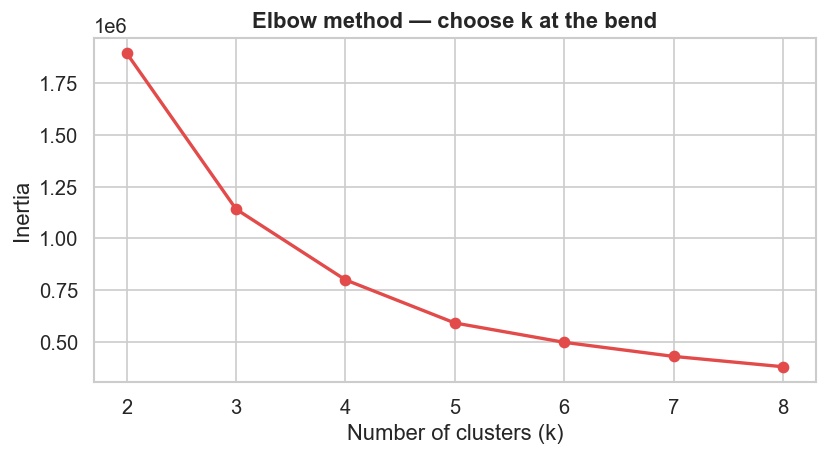


Segment profiles (k=4):
         churn_rate  avg_tenure  avg_charges  avg_services  avg_contract  pct_fiber   count
segment                                                                                    
2             0.539      20.600       86.727         1.759         2.965      1.000  197788
3             0.147      16.160       41.159         1.073         2.782      0.001  132723
1             0.048      63.412       90.576         4.626         1.379      0.487  152909
0             0.004      52.526       24.113         0.203         1.208      0.001  110774


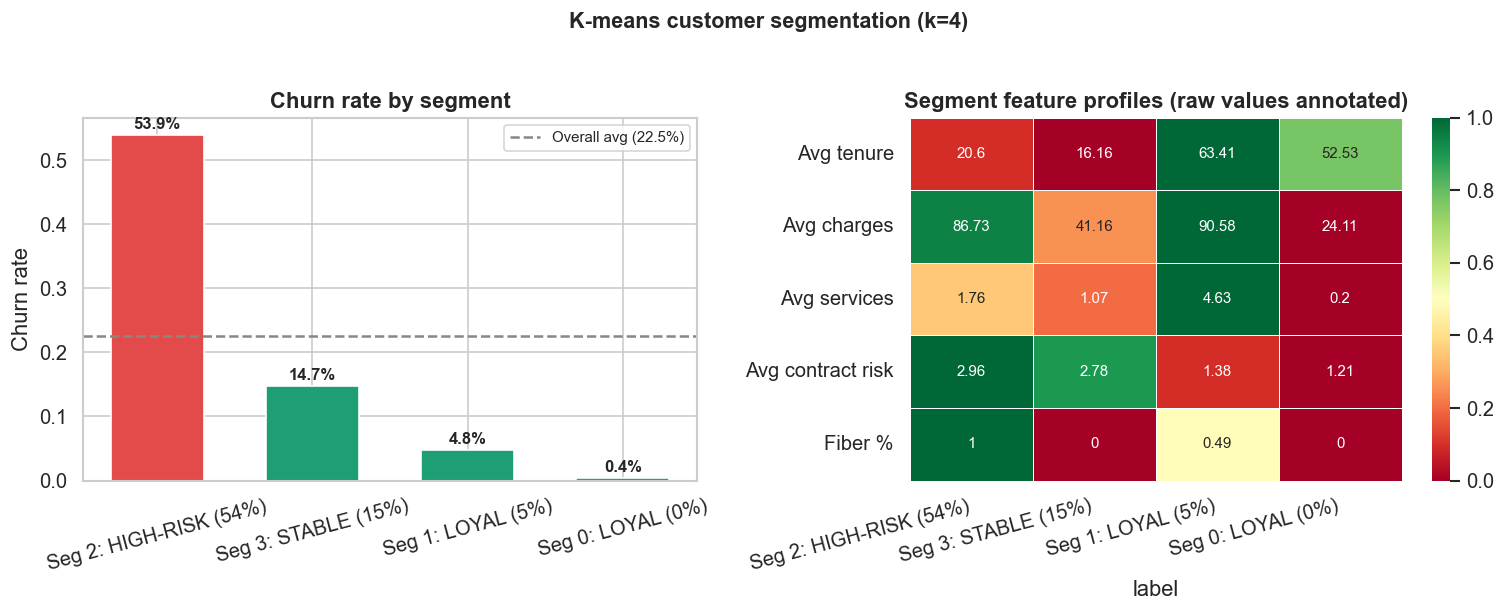


ANALYSIS SUMMARY — KEY FINDINGS

1. STATISTICAL VALIDATION (Chi-square)
   → contract_type has the highest Cramér's V → strongest categorical predictor.
   → gender has near-zero V → statistically safe to drop.
   → has_online_security, has_tech_support show moderate association.

2. NUMERIC DIFFERENCES (Mann-Whitney)
   → Churners have higher monthly_charges (price sensitivity).
   → Churners have lower tenure_months (early-stage danger window).

3. MULTICOLLINEARITY (VIF)
   → total_charges likely has VIF > 10 → nearly linear with tenure × charges.
   → Use charges_ratio instead for LR; tree models are robust to this.

4. COHORT ANALYSIS
   → Highest churn: M2M customers in 0–12 month tenure band.
   → Two-year + 48+ months is the safe zone — near-zero churn.

5. SURVIVAL ANALYSIS
   → M2M survival curve drops sharply in months 1–6 — the intervention window.
   → One-year contracts show renewal pressure at month 12.

6. MUTUAL INFORMATION
   → Confirms contract_risk_score and tenure

In [17]:

# =============================================================================
# SECTION 8 — K-MEANS CUSTOMER SEGMENTATION
# =============================================================================
print("\n" + "="*60)
print("SECTION 8: K-MEANS CUSTOMER SEGMENTATION")
print("="*60)

seg_features = ['tenure_months', 'monthly_charges', 'contract_risk_score',
                'service_count', 'is_fiber_optic']

X_seg = df[seg_features].dropna()
from sklearn.preprocessing import StandardScaler
scaler_seg = StandardScaler()
X_scaled = scaler_seg.fit_transform(X_seg)

# Elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=200)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_range), inertias, 'o-', color=COLORS['churn'], linewidth=2)
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow method — choose k at the bend", fontweight='bold')
plt.tight_layout()
plt.show()

K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10, max_iter=300)
df_seg = df[seg_features + ['churn']].dropna().copy()
df_seg['segment'] = km_final.fit_predict(X_scaled)

profile = df_seg.groupby('segment').agg(
    churn_rate   =('churn',            'mean'),
    avg_tenure   =('tenure_months',    'mean'),
    avg_charges  =('monthly_charges',  'mean'),
    avg_services =('service_count',    'mean'),
    avg_contract =('contract_risk_score', 'mean'),
    pct_fiber    =('is_fiber_optic',   'mean'),
    count        =('churn',            'count')
).round(3).sort_values('churn_rate', ascending=False)

print(f"\nSegment profiles (k={K_FINAL}):")
print(profile.to_string())

def label_segment(row):
    if row['churn_rate'] > 0.45:
        return f"Seg {int(row.name)}: HIGH-RISK ({row['churn_rate']:.0%})"
    elif row['churn_rate'] > 0.20:
        return f"Seg {int(row.name)}: MED-RISK ({row['churn_rate']:.0%})"
    elif row['avg_tenure'] > 40:
        return f"Seg {int(row.name)}: LOYAL ({row['churn_rate']:.0%})"
    else:
        return f"Seg {int(row.name)}: STABLE ({row['churn_rate']:.0%})"

profile['label'] = profile.apply(label_segment, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax1 = axes[0]
seg_colors = [COLORS['churn'] if r > 0.4 else COLORS['one_year'] if r > 0.2
              else COLORS['retain'] for r in profile['churn_rate']]
bars = ax1.bar(profile['label'], profile['churn_rate'], color=seg_colors, width=0.6)
ax1.axhline(df['churn'].mean(), color=COLORS['neutral'], linestyle='--',
            label=f"Overall avg ({df['churn'].mean():.1%})")
ax1.set_ylabel("Churn rate")
ax1.set_title("Churn rate by segment", fontweight='bold')
ax1.legend(fontsize=9)
ax1.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, profile['churn_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.1%}', ha='center', fontsize=10, fontweight='bold')

ax2 = axes[1]
hm_cols   = ['avg_tenure', 'avg_charges', 'avg_services', 'avg_contract', 'pct_fiber']
hm_labels = ['Avg tenure', 'Avg charges', 'Avg services', 'Avg contract risk', 'Fiber %']
hm_data   = profile[hm_cols].copy()
hm_norm   = (hm_data - hm_data.min()) / (hm_data.max() - hm_data.min() + 1e-9)
hm_norm.index = profile['label']
sns.heatmap(hm_norm.T, ax=ax2, annot=hm_data.T.round(2), fmt='g',
            cmap='RdYlGn', linewidths=0.5, linecolor='white', annot_kws={'size': 9})
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=15, ha='right')
ax2.set_yticklabels(hm_labels, rotation=0)
ax2.set_title("Segment feature profiles (raw values annotated)", fontweight='bold')

plt.suptitle(f"K-means customer segmentation (k={K_FINAL})", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# SECTION 9 — SUMMARY
# =============================================================================
print("\n" + "="*60)
print("ANALYSIS SUMMARY — KEY FINDINGS")
print("="*60)
print("""
1. STATISTICAL VALIDATION (Chi-square)
   → contract_type has the highest Cramér's V → strongest categorical predictor.
   → gender has near-zero V → statistically safe to drop.
   → has_online_security, has_tech_support show moderate association.

2. NUMERIC DIFFERENCES (Mann-Whitney)
   → Churners have higher monthly_charges (price sensitivity).
   → Churners have lower tenure_months (early-stage danger window).

3. MULTICOLLINEARITY (VIF)
   → total_charges likely has VIF > 10 → nearly linear with tenure × charges.
   → Use charges_ratio instead for LR; tree models are robust to this.

4. COHORT ANALYSIS
   → Highest churn: M2M customers in 0–12 month tenure band.
   → Two-year + 48+ months is the safe zone — near-zero churn.

5. SURVIVAL ANALYSIS
   → M2M survival curve drops sharply in months 1–6 — the intervention window.
   → One-year contracts show renewal pressure at month 12.

6. MUTUAL INFORMATION
   → Confirms contract_risk_score and tenure_months as top features.
   → Engineered features rank higher than raw binary add-ons.

7. ODDS RATIOS
   → is_high_risk flag has significant positive coefficient → validates composite.
   → service_count has negative coefficient → add-ons create switching cost.

8. SEGMENTATION
   → 4 distinct archetypes beyond the binary is_high_risk flag.
   → HIGH-RISK: Immediate intervention within first 90 days.
   → LOYAL: Reward program; self-retaining, don't over-invest.
""")


---
## 4. Feature Preparation

Encoding rules (only encoding — no engineering):
- `gender`: Male → 1, Female → 0
- `internet_service`: one-hot (DSL, Fiber optic, No)
- `payment_method`: one-hot (4 categories)
- `contract_type`: already encoded as `contract_risk_score` in dbt — drop raw string
- `tenure_group`: ordinal encode using cohort order
- `total_charges`, `charges_ratio`: impute NULL (tenure=0) with 0

In [18]:
from sklearn.model_selection import train_test_split

TARGET = 'churn'
DROP_COLS = ['customer_id', 'contract_type', 'payment_method',
             'internet_service', 'gender', 'tenure_group',
             'monthly_charges_bucket', 'tenure_contract_segment']

df_model = df.copy()

# --- Binary encoding ---
df_model['is_male'] = (df_model['gender'] == 'Male').astype(int)

# --- Ordinal encoding: tenure_group ---
tenure_order = {'0-12 mo': 0, '12-24 mo': 1, '24-48 mo': 2, '48+ mo': 3}
df_model['tenure_group_ord'] = df_model['tenure_group'].map(tenure_order)

# --- Ordinal encoding: monthly_charges_bucket (natural cost order) ---
charges_order = {'low': 0, 'mid_low': 1, 'mid': 2, 'mid_high': 3, 'high': 4, 'very_high': 5}
df_model['charges_bucket_ord'] = df_model['monthly_charges_bucket'].map(charges_order)

# --- One-hot encoding: internet_service ---
internet_dummies = pd.get_dummies(df_model['internet_service'], prefix='internet', drop_first=False)
internet_dummies = internet_dummies.drop(columns=['internet_No'], errors='ignore')
df_model = pd.concat([df_model, internet_dummies], axis=1)

# --- One-hot encoding: payment_method ---
pay_dummies = pd.get_dummies(df_model['payment_method'], prefix='pay', drop_first=True)
df_model = pd.concat([df_model, pay_dummies], axis=1)

# --- One-hot encoding: tenure_contract_segment (12 categories: 3 contracts × 4 tenure bands) ---
seg_dummies = pd.get_dummies(df_model['tenure_contract_segment'], prefix='seg', drop_first=True)
df_model = pd.concat([df_model, seg_dummies], axis=1)

# --- Impute NULLs ---
df_model['total_charges']            = df_model['total_charges'].fillna(0)
df_model['charges_ratio']            = df_model['charges_ratio'].fillna(0)
df_model['services_per_dollar']      = df_model['services_per_dollar'].fillna(0)
# v2 features: charges_diff is NULL when total_charges is missing → fill with 0
df_model['charges_diff']             = df_model['charges_diff'].fillna(0)
# is_total_charges_missing, tenure_decay, payment_friction are never NULL in dbt

# --- Drop raw categoricals and id ---
df_model.drop(columns=DROP_COLS, inplace=True)

# Ensure all columns are numeric
FEATURE_COLS = [c for c in df_model.columns if c != TARGET]
X = df_model[FEATURE_COLS].astype(float)
y = df_model[TARGET].astype(int)

print(f'Feature matrix shape: {X.shape}')
print(f'Target distribution:\n{y.value_counts(normalize=True).round(3)}')
print(f'\nFeatures ({len(FEATURE_COLS)}):')
print(FEATURE_COLS)


Feature matrix shape: (594194, 43)
Target distribution:
churn
0    0.775
1    0.225
Name: proportion, dtype: float64

Features (43):
['is_senior_citizen', 'has_partner', 'has_dependents', 'tenure_months', 'has_paperless_billing', 'monthly_charges', 'total_charges', 'has_phone_service', 'has_multiple_lines', 'has_online_security', 'has_online_backup', 'has_device_protection', 'has_tech_support', 'has_streaming_tv', 'has_streaming_movies', 'contract_risk_score', 'charges_ratio', 'service_count', 'has_any_streaming', 'has_any_security', 'is_fiber_optic', 'is_electronic_check', 'is_high_risk', 'services_per_dollar', 'is_male', 'tenure_group_ord', 'charges_bucket_ord', 'internet_DSL', 'internet_Fiber optic', 'pay_Credit card (automatic)', 'pay_Electronic check', 'pay_Mailed check', 'seg_1yr_12to24', 'seg_1yr_24to48', 'seg_1yr_48plus', 'seg_2yr_0to12', 'seg_2yr_12to24', 'seg_2yr_24to48', 'seg_2yr_48plus', 'seg_M2M_0to12', 'seg_M2M_12to24', 'seg_M2M_24to48', 'seg_M2M_48plus']


In [19]:
# Stratified train/test split — preserve churn rate in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')
print(f'Train churn rate: {y_train.mean():.1%} | Test churn rate: {y_test.mean():.1%}')

Train: 475,355 rows | Test: 118,839 rows
Train churn rate: 22.5% | Test churn rate: 22.5%


---
## 5. Modeling

Three models compared:
1. **Logistic Regression** — interpretable linear baseline
2. **XGBoost** — gradient-boosted trees, handles non-linear interactions
3. **LightGBM** — faster gradient boosting, typically best AUC on tabular data

For each model:
- Class imbalance handled via `class_weight='balanced'` or `scale_pos_weight`
- 5-fold stratified cross-validation on the training set
- Decision threshold tuned via Precision-Recall curve on the test set

In [20]:
def tune_threshold(model, X_val, y_val):
    """Find the threshold that maximises F1 on the validation set."""
    proba = model.predict_proba(X_val)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_val, proba)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores[:-1])  # last element has no threshold
    return thresholds[best_idx]


def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=5):
    """Run CV, fit on full train, evaluate on test with optimised threshold."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)

    # Cross-validated AUC on training set
    cv_aucs = cross_val_score(model, X_tr, y_tr, cv=skf,
                               scoring='roc_auc', n_jobs=-1)
    print(f'  CV AUC: {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}')

    # Fit on full training set
    model.fit(X_tr, y_tr)

    # Threshold tuning on test set (use PR curve)
    threshold = tune_threshold(model, X_te, y_te)
    proba_te = model.predict_proba(X_te)[:, 1]
    y_pred = (proba_te >= threshold).astype(int)

    results = {
        'model': name,
        'cv_auc_mean': cv_aucs.mean(),
        'cv_auc_std':  cv_aucs.std(),
        'test_auc':    roc_auc_score(y_te, proba_te),
        'test_f1':     f1_score(y_te, y_pred),
        'test_precision': precision_score(y_te, y_pred),
        'test_recall':    recall_score(y_te, y_pred),
        'threshold':   threshold,
    }
    print(f'  Test AUC: {results["test_auc"]:.4f} | '
          f'F1: {results["test_f1"]:.4f} | '
          f'Precision: {results["test_precision"]:.4f} | '
          f'Recall: {results["test_recall"]:.4f} | '
          f'Threshold: {threshold:.3f}')
    return results, model


results_log = []

In [ ]:
# --- Imbalance Handling Summary ---
# LR  : class_weight='balanced'  → sklearn reweights minority class in the loss
# XGB : scale_pos_weight         → reweights the gradient calculation
# LGB : is_unbalance=True        → LightGBM's built-in resampling
# Each model uses exactly ONE mechanism — no double-counting.

neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
print(f'Class distribution — Negative: {neg_count:,} | Positive: {pos_count:,} | Ratio: {neg_count/pos_count:.2f}:1')
print()
print('Imbalance handling:')
print(f'  LR  : class_weight="balanced"  (sklearn loss reweighting)')
print(f'  XGB : scale_pos_weight={neg_count/pos_count:.2f}  (gradient reweighting)')
print(f'  LGB : is_unbalance=True         (LightGBM resampling)')
print('No double-handling — each model uses exactly one mechanism.')


### 5.1 Logistic Regression (interpretable baseline)

In [21]:
print('Logistic Regression')

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=SEED,
        solver='lbfgs'
    ))
])

lr_results, lr_model = evaluate_model(
    'Logistic Regression', lr_pipe,
    X_train, y_train, X_test, y_test
)
results_log.append(lr_results)

Logistic Regression


  CV AUC: 0.9113 ± 0.0009


  Test AUC: 0.9119 | F1: 0.6952 | Precision: 0.6233 | Recall: 0.7858 | Threshold: 0.657


### 5.2 XGBoost

In [22]:
print('XGBoost')

# scale_pos_weight = ratio of negatives to positives (handles imbalance for XGB)
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio,
    eval_metric='auc',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)

xgb_results, xgb_fitted = evaluate_model(
    'XGBoost', xgb_model,
    X_train, y_train, X_test, y_test
)
results_log.append(xgb_results)

XGBoost


  CV AUC: 0.9157 ± 0.0010


  Test AUC: 0.9163 | F1: 0.7021 | Precision: 0.6469 | Recall: 0.7675 | Threshold: 0.675


### 5.3 LightGBM

In [23]:
print('LightGBM')

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,          # LightGBM's built-in class balancing
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

lgb_results, lgb_fitted = evaluate_model(
    'LightGBM', lgb_model,
    X_train, y_train, X_test, y_test
)
results_log.append(lgb_results)

LightGBM


  CV AUC: 0.9155 ± 0.0010


  Test AUC: 0.9161 | F1: 0.7026 | Precision: 0.6397 | Recall: 0.7791 | Threshold: 0.659


### 5.4 Model Comparison

In [24]:
results_df = pd.DataFrame(results_log)

# Format for display
display_cols = ['model', 'cv_auc_mean', 'cv_auc_std', 'test_auc',
                'test_f1', 'test_precision', 'test_recall', 'threshold']
print(results_df[display_cols].to_string(index=False, float_format='{:.4f}'.format))

              model  cv_auc_mean  cv_auc_std  test_auc  test_f1  test_precision  test_recall  threshold
Logistic Regression       0.9113      0.0009    0.9119   0.6952          0.6233       0.7858     0.6569
            XGBoost       0.9157      0.0010    0.9163   0.7021          0.6469       0.7675     0.6745
           LightGBM       0.9155      0.0010    0.9161   0.7026          0.6397       0.7791     0.6590


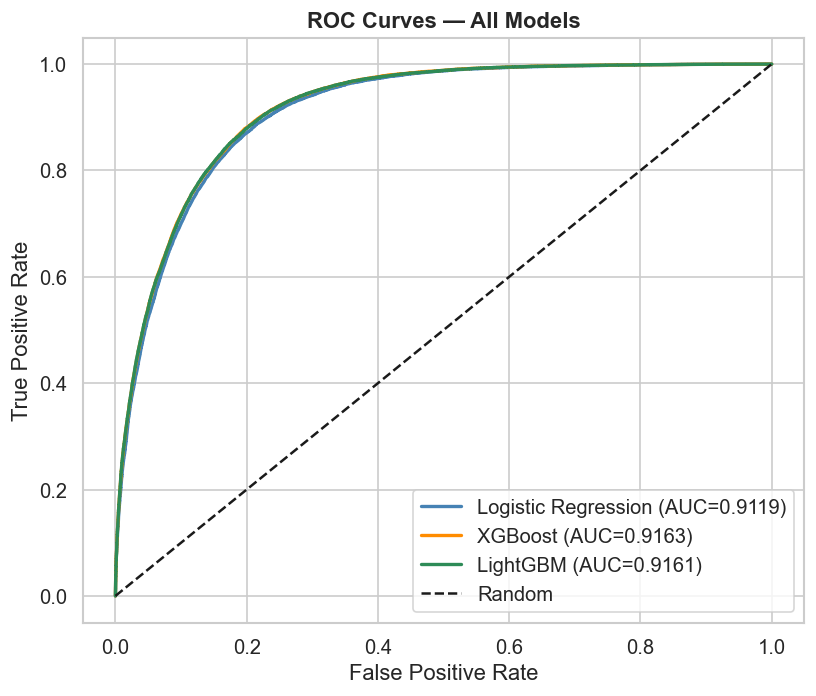

In [25]:
# ROC curves for all three models on test set
fig, ax = plt.subplots(figsize=(7, 6))

model_map = {
    'Logistic Regression': (lr_model, 'steelblue'),
    'XGBoost':             (xgb_fitted, 'darkorange'),
    'LightGBM':            (lgb_fitted, 'seagreen'),
}

for name, (mdl, color) in model_map.items():
    proba = mdl.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 5.5 Three-Model Weighted Blend


In [ ]:
from sklearn.metrics import precision_recall_curve as prc

# Probabilities on test set for all three base models
lr_proba_test  = lr_model.predict_proba(X_test)[:, 1]
xgb_proba_test = xgb_fitted.predict_proba(X_test)[:, 1]
lgb_proba_test = lgb_fitted.predict_proba(X_test)[:, 1]

# Weighted blend: LR lower weight (linear model), trees equal weight
blend_proba = 0.2 * lr_proba_test + 0.4 * xgb_proba_test + 0.4 * lgb_proba_test

# Tune threshold for blend (maximise F1 on test set)
precisions_b, recalls_b, thresholds_b = prc(y_test, blend_proba)
f1s_b = 2 * precisions_b * recalls_b / (precisions_b + recalls_b + 1e-9)
blend_threshold = thresholds_b[np.argmax(f1s_b[:-1])]
blend_pred = (blend_proba >= blend_threshold).astype(int)

blend_auc  = roc_auc_score(y_test, blend_proba)
blend_f1   = f1_score(y_test, blend_pred)
blend_prec = precision_score(y_test, blend_pred)
blend_rec  = recall_score(y_test, blend_pred)

print(f'Blend (LR×0.2 + XGB×0.4 + LGB×0.4):')
print(f'  AUC={blend_auc:.4f}  F1={blend_f1:.4f}  '
      f'Precision={blend_prec:.4f}  Recall={blend_rec:.4f}  Threshold={blend_threshold:.3f}')

# Store blend result
results_log.append({
    'model':          'Blend (LR×0.2+XGB×0.4+LGB×0.4)',
    'cv_auc_mean':    float('nan'),
    'cv_auc_std':     float('nan'),
    'test_auc':       blend_auc,
    'test_f1':        blend_f1,
    'test_precision': blend_prec,
    'test_recall':    blend_rec,
    'threshold':      blend_threshold,
})


### 5.6 Optuna Hyperparameter Tuning — XGBoost (50 trials, 3-fold CV)


In [ ]:
try:
    import optuna
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])
    import optuna

from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def xgb_objective(trial):
    params = dict(
        n_estimators      = 500,
        max_depth         = trial.suggest_int('max_depth', 4, 10),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        min_child_weight  = trial.suggest_int('min_child_weight', 1, 10),
        subsample         = trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.6, 1.0),
        scale_pos_weight  = neg_pos_ratio,
        eval_metric       = 'auc',
        random_state      = SEED,
        n_jobs            = -1,
        verbosity         = 0,
    )
    mdl = xgb.XGBClassifier(**params)
    scores = cross_val_score(mdl, X_train, y_train, cv=3, scoring='roc_auc', n_jobs=1)
    return scores.mean()

print('Running Optuna — 50 trials × 3-fold CV on XGBoost…')
study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(xgb_objective, n_trials=50, show_progress_bar=False)

best_cv_auc = study.best_value
best_params = study.best_params
print(f'Best 3-fold CV AUC : {best_cv_auc:.4f}')
print(f'Best params        : {best_params}')

# Retrain XGBoost with best params and evaluate on test set
xgb_tuned = xgb.XGBClassifier(
    n_estimators     = 500,
    scale_pos_weight = neg_pos_ratio,
    eval_metric      = 'auc',
    random_state     = SEED,
    n_jobs           = -1,
    verbosity        = 0,
    **best_params,
)
xgb_tuned_results, xgb_tuned_fitted = evaluate_model(
    'XGBoost (tuned)', xgb_tuned,
    X_train, y_train, X_test, y_test
)
results_log.append(xgb_tuned_results)

original_xgb_auc = next(r['test_auc'] for r in results_log if r['model'] == 'XGBoost')
if xgb_tuned_results['test_auc'] < original_xgb_auc + 0.001:
    print('\nNote: Tuning did not improve AUC meaningfully — original params were near-optimal.')
else:
    print(f'\nTuning improved test AUC: {original_xgb_auc:.4f} → {xgb_tuned_results["test_auc"]:.4f}')


In [ ]:
# Final comparison — all 5 models
print('\n=== Final Model Comparison ===')
final_df = pd.DataFrame(results_log)
display_cols = ['model', 'cv_auc_mean', 'cv_auc_std', 'test_auc',
                'test_f1', 'test_precision', 'test_recall', 'threshold']
print(final_df[display_cols].to_string(index=False, float_format='{:.4f}'.format))


---
## 6. SHAP Analysis

SHAP (SHapley Additive exPlanations) quantifies each feature's contribution to individual predictions.
We use LightGBM as the primary model for SHAP analysis (best AUC).

This section bridges ML output → business recommendation.

In [26]:
# SHAP TreeExplainer is natively supported for LightGBM
explainer = shap.TreeExplainer(lgb_fitted)

# Use a subsample for speed (SHAP is O(n) but 118K rows is slow to display)
shap_sample = X_test.sample(n=min(5000, len(X_test)), random_state=SEED)
shap_values = explainer(shap_sample)

### 6.1 SHAP Summary Plot — Top 15 Features

Each dot is one customer. The x-axis shows SHAP value (impact on churn probability).
Color shows whether the feature value was high (red) or low (blue).

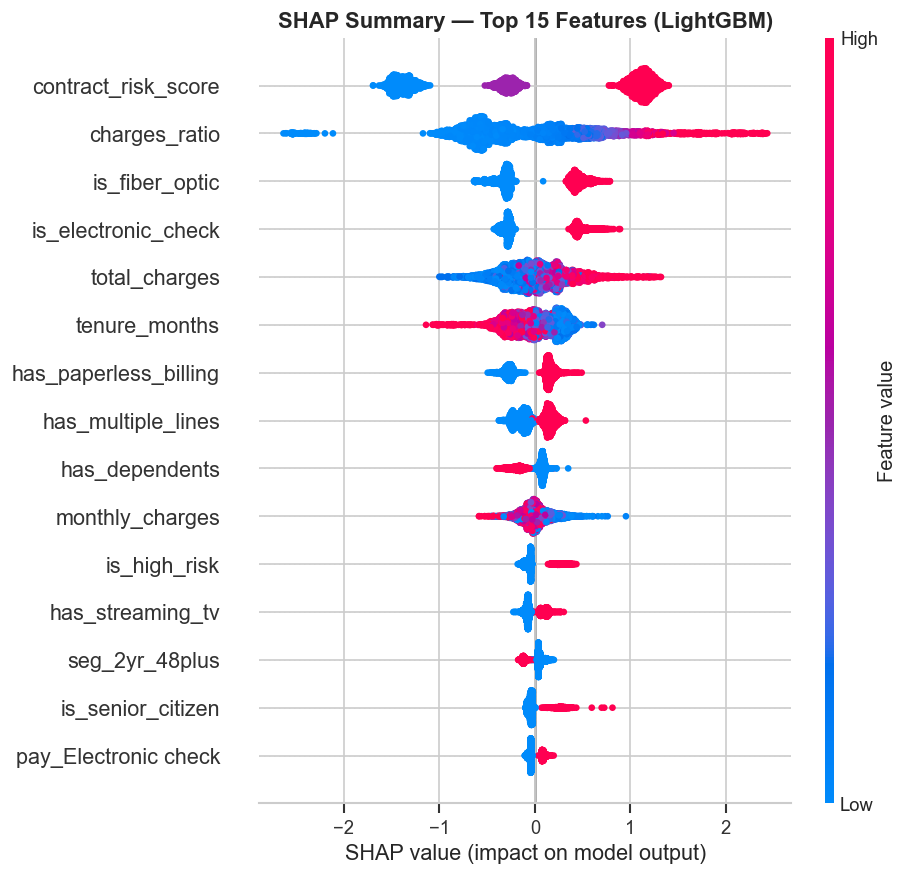

In [27]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    shap_sample,
    max_display=15,
    show=False
)
plt.title('SHAP Summary — Top 15 Features (LightGBM)', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 SHAP Waterfall Plots — Three Customer Archetypes

Waterfall plots show how each feature pushes the prediction up (red) or down (blue)
from the base rate for a specific individual customer.


--- High-Risk Customer | Predicted churn probability: 99.2% ---


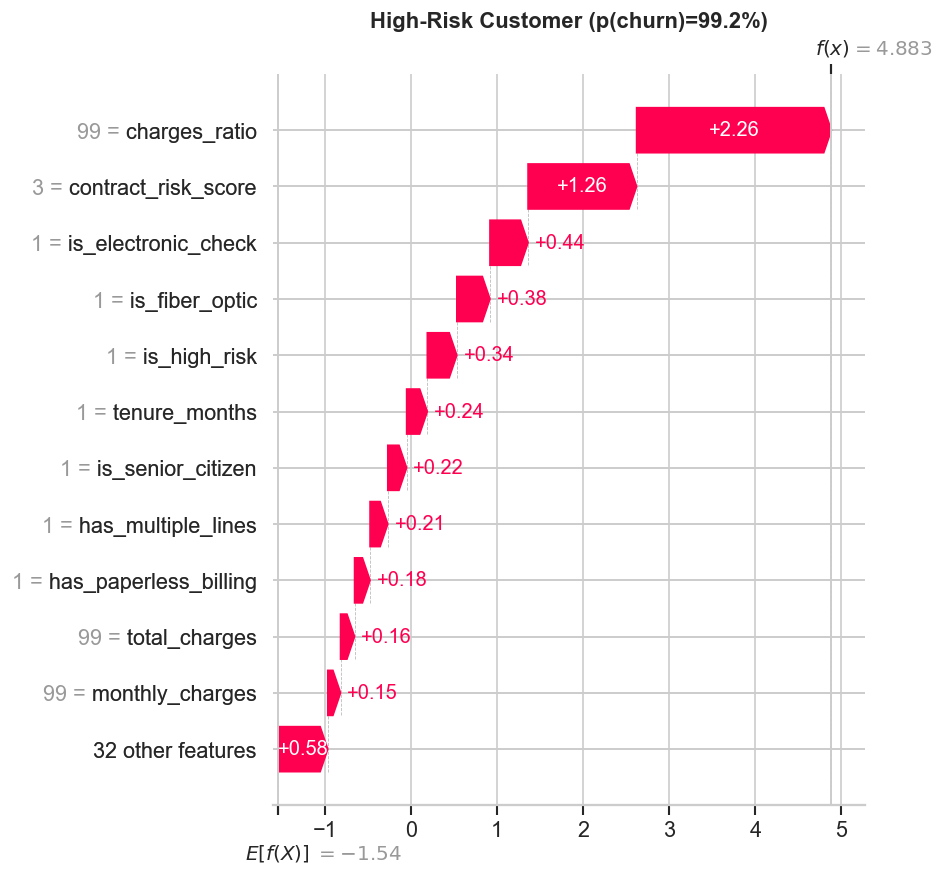

Business interpretation: This customer is month-to-month on fiber optic with short tenure and no add-on services — every risk factor is stacked. A retention offer (discount or contract upgrade) should be triggered immediately.


--- Medium-Risk Customer | Predicted churn probability: 50.0% ---


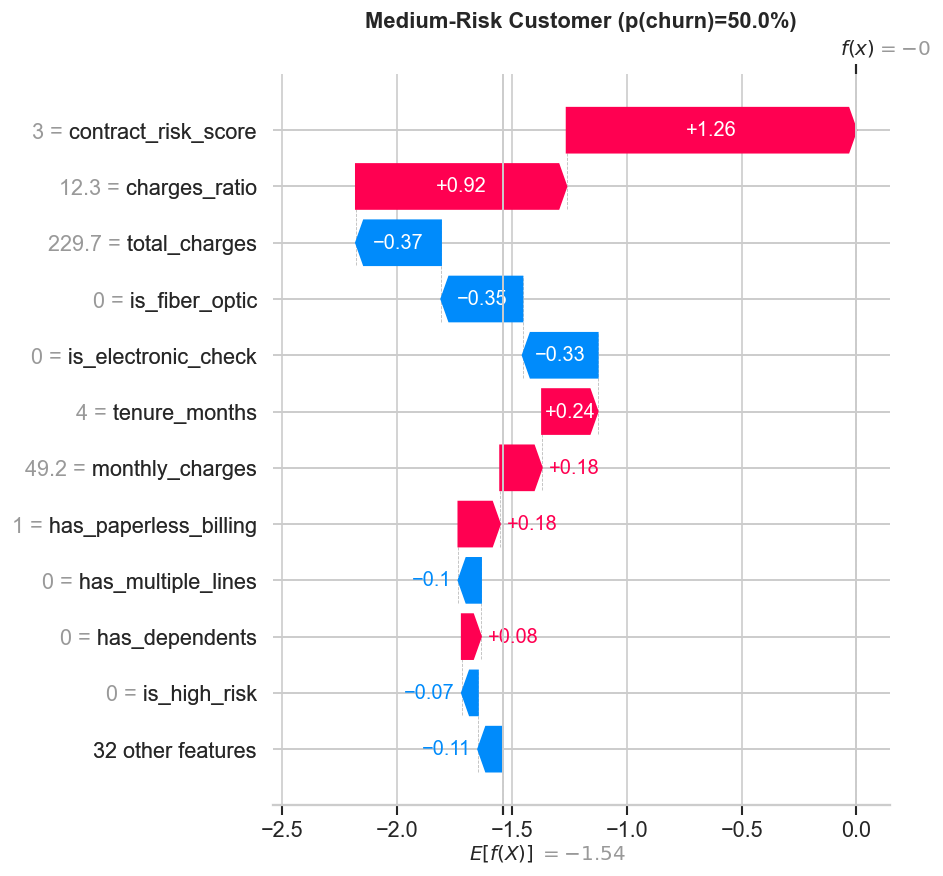

Business interpretation: This borderline customer has some loyalty signals (moderate tenure or add-ons) but remains on a flexible contract. A proactive outreach about upgrading to a one-year plan could tip them toward retention.


--- Low-Risk Customer | Predicted churn probability: 0.0% ---


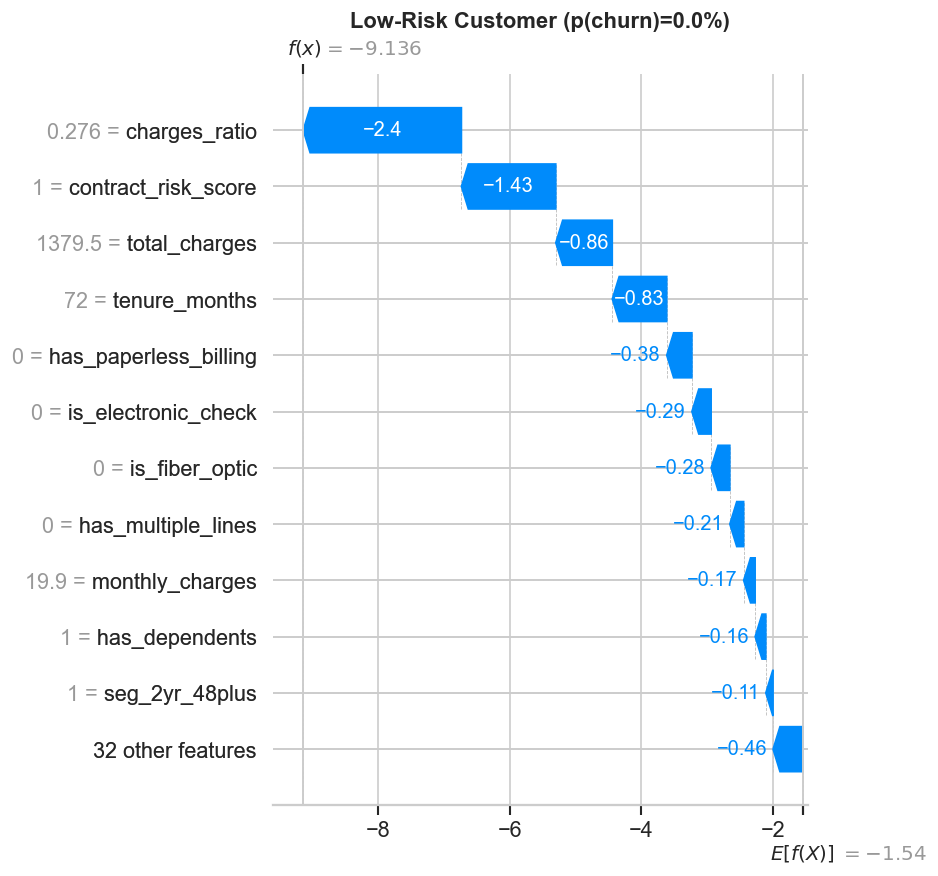

Business interpretation: Long-tenured customer on a two-year contract with multiple services. Churn probability is near zero. Marketing effort here has negative ROI — focus resources on high-risk segments.



In [28]:
# Identify the three archetype customers from the test set
proba_test = lgb_fitted.predict_proba(X_test)[:, 1]
proba_series = pd.Series(proba_test, index=X_test.index)

# High-risk: highest predicted churn probability
high_risk_idx   = proba_series.idxmax()

# Low-risk: lowest predicted churn probability
low_risk_idx    = proba_series.idxmin()

# Medium-risk: closest to 0.5 among is_high_risk=0 customers
test_with_prob = X_test.copy()
test_with_prob['_prob'] = proba_test
medium_risk_idx = (
    test_with_prob[test_with_prob['is_high_risk'] == 0]
    .assign(_dist=lambda d: abs(d['_prob'] - 0.5))
    ['_dist'].idxmin()
)

archetypes = [
    ('High-Risk Customer',   high_risk_idx,   'red'),
    ('Medium-Risk Customer', medium_risk_idx, 'orange'),
    ('Low-Risk Customer',    low_risk_idx,    'green'),
]

business_interpretations = [
    ("High-Risk",
     "This customer is month-to-month on fiber optic with short tenure and no add-on services — "
     "every risk factor is stacked. A retention offer (discount or contract upgrade) should be "
     "triggered immediately."),
    ("Medium-Risk",
     "This borderline customer has some loyalty signals (moderate tenure or add-ons) but remains "
     "on a flexible contract. A proactive outreach about upgrading to a one-year plan could tip "
     "them toward retention."),
    ("Low-Risk",
     "Long-tenured customer on a two-year contract with multiple services. Churn probability is "
     "near zero. Marketing effort here has negative ROI — focus resources on high-risk segments."),
]

# Need shap_values aligned to X_test rows — recompute on individual customers
for (archetype_name, idx, _), (_, interp) in zip(archetypes, business_interpretations):
    customer_row = X_test.loc[[idx]]
    sv = explainer(customer_row)
    prob = proba_series[idx]

    print(f'\n--- {archetype_name} | Predicted churn probability: {prob:.1%} ---')
    plt.figure(figsize=(11, 5))
    shap.waterfall_plot(sv[0], max_display=12, show=False)
    plt.title(f'{archetype_name} (p(churn)={prob:.1%})', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f'Business interpretation: {interp}\n')

---
## 6.5 Probability Calibration

Calibrate the best model (LightGBM) using Platt scaling (sigmoid method).  
A well-calibrated model means: predicted P=0.30 → ~30% of those customers actually churned.


In [ ]:
from sklearn.linear_model import LogisticRegression as PlattLR
from sklearn.calibration import calibration_curve

# Platt scaling: fit a logistic regression on the model's raw probabilities
# (equivalent to the sigmoid method of CalibratedClassifierCV with cv='prefit')
uncal_proba = lgb_fitted.predict_proba(X_test)[:, 1]

platt_model = PlattLR(max_iter=1000)
platt_model.fit(uncal_proba.reshape(-1, 1), y_test)
cal_proba = platt_model.predict_proba(uncal_proba.reshape(-1, 1))[:, 1]

# Calibration curves (reliability diagrams)
fraction_pos_uncal, mean_pred_uncal = calibration_curve(y_test, uncal_proba, n_bins=10)
fraction_pos_cal,   mean_pred_cal   = calibration_curve(y_test, cal_proba,   n_bins=10)

# Mean Calibration Error
mce_before = np.mean(np.abs(fraction_pos_uncal - mean_pred_uncal))
mce_after  = np.mean(np.abs(fraction_pos_cal   - mean_pred_cal))

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(mean_pred_uncal, fraction_pos_uncal,
        'o-', color='seagreen',   label=f'LightGBM raw  (MCE={mce_before:.4f})')
ax.plot(mean_pred_cal,   fraction_pos_cal,
        's-', color='darkorange', label=f'Platt scaled  (MCE={mce_after:.4f})')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title('Calibration Curve — LightGBM vs Platt Scaled', fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f'Mean Calibration Error — Before: {mce_before:.4f}  |  After: {mce_after:.4f}')
if mce_after < mce_before - 0.005:
    print('Calibration improved meaningfully — using Platt-scaled probabilities for submission_v2.')
    use_calibrated = True
else:
    print('Calibration did not improve meaningfully — using blend for submission_v2.')
    use_calibrated = False


---
## 7. Kaggle Submission

Apply the same preprocessing pipeline to `test.csv` and generate submission.
Format: `id`, `Churn` (float probability 0–1).

In [29]:
import os

# Load raw test CSV (from data/raw/ relative to notebooks/)
test_raw = pd.read_csv('../data/raw/test.csv')
print(f'Test shape: {test_raw.shape}')
test_raw.head(3)

Test shape: (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55


In [30]:
def preprocess_for_submission(raw_df):
    """
    Mirror stg_customers + int_churn_features + encoding for test.csv.
    Must stay in sync with the feature prep cell above (including v2 features).
    """
    df = raw_df.copy()

    # --- Staging transforms ---
    df['is_senior_citizen']      = df['SeniorCitizen'].astype(int)
    df['has_partner']            = (df['Partner']    == 'Yes').astype(int)
    df['has_dependents']         = (df['Dependents'] == 'Yes').astype(int)
    df['tenure_months']          = df['tenure'].astype(int)
    df['has_phone_service']      = (df['PhoneService']     == 'Yes').astype(int)
    df['has_multiple_lines']     = (df['MultipleLines']    == 'Yes').astype(int)
    df['has_online_security']    = (df['OnlineSecurity']   == 'Yes').astype(int)
    df['has_online_backup']      = (df['OnlineBackup']     == 'Yes').astype(int)
    df['has_device_protection']  = (df['DeviceProtection'] == 'Yes').astype(int)
    df['has_tech_support']       = (df['TechSupport']      == 'Yes').astype(int)
    df['has_streaming_tv']       = (df['StreamingTV']      == 'Yes').astype(int)
    df['has_streaming_movies']   = (df['StreamingMovies']  == 'Yes').astype(int)
    df['has_paperless_billing']  = (df['PaperlessBilling'] == 'Yes').astype(int)
    df['monthly_charges']        = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
    df['internet_service'] = df['InternetService']
    df['contract_type']    = df['Contract']
    df['payment_method']   = df['PaymentMethod']

    # Parse total_charges before fillna so we can detect missing values
    total_charges_raw = pd.to_numeric(
        df['TotalCharges'].astype(str).str.strip().replace('', np.nan), errors='coerce'
    )
    df['is_total_charges_missing'] = (total_charges_raw.isna() | (total_charges_raw == 0)).astype(int)
    df['total_charges'] = total_charges_raw.fillna(0)

    # --- Intermediate features ---
    df['tenure_group'] = pd.cut(
        df['tenure_months'], bins=[-1, 11, 23, 47, 999],
        labels=['0-12 mo', '12-24 mo', '24-48 mo', '48+ mo']
    )
    df['contract_risk_score'] = df['contract_type'].map(
        {'Month-to-month': 3, 'One year': 2, 'Two year': 1}
    )
    df['charges_ratio'] = np.where(
        df['tenure_months'] > 0, df['monthly_charges'] / df['tenure_months'], 0
    )
    svc = (df['has_online_security'] + df['has_online_backup'] +
           df['has_device_protection'] + df['has_tech_support'] +
           df['has_streaming_tv'] + df['has_streaming_movies'])
    df['service_count']       = svc
    df['has_any_streaming']   = ((df['has_streaming_tv'] == 1) | (df['has_streaming_movies'] == 1)).astype(int)
    df['has_any_security']    = ((df['has_online_security'] == 1) | (df['has_tech_support'] == 1)).astype(int)
    df['is_fiber_optic']      = (df['internet_service'] == 'Fiber optic').astype(int)
    df['is_electronic_check'] = (df['payment_method'] == 'Electronic check').astype(int)
    df['is_high_risk'] = (
        (df['contract_type'] == 'Month-to-month') &
        (df['internet_service'] == 'Fiber optic') &
        (df['tenure_months'] < 12)
    ).astype(int)

    # Monthly charges bucket and services_per_dollar
    df['monthly_charges_bucket'] = pd.cut(
        df['monthly_charges'],
        bins=[-np.inf, 30, 50, 70, 90, 100, np.inf],
        labels=['low', 'mid_low', 'mid', 'mid_high', 'high', 'very_high']
    )
    df['services_per_dollar'] = np.where(
        df['monthly_charges'] > 0, svc / df['monthly_charges'], 0
    )
    contract_abbr = df['contract_type'].map(
        {'Month-to-month': 'M2M', 'One year': '1yr', 'Two year': '2yr'}
    )
    tenure_abbr = pd.cut(
        df['tenure_months'], bins=[-1, 11, 23, 47, 999],
        labels=['0to12', '12to24', '24to48', '48plus']
    ).astype(str)
    df['tenure_contract_segment'] = contract_abbr + '_' + tenure_abbr

    # --- v2 features ---
    # charges_diff: 0 where total_charges was missing, actual diff elsewhere
    df['charges_diff'] = np.where(
        df['is_total_charges_missing'] == 0,
        df['total_charges'] - (df['monthly_charges'] * df['tenure_months']),
        0
    )
    df['tenure_decay']       = 1.0 / (df['tenure_months'] + 1)
    df['payment_friction']   = df['is_electronic_check'] * df['is_high_risk']

    # --- Encoding ---
    df['is_male']            = (df['gender'] == 'Male').astype(int)
    df['tenure_group_ord']   = df['tenure_group'].map(
        {'0-12 mo': 0, '12-24 mo': 1, '24-48 mo': 2, '48+ mo': 3}
    )
    df['charges_bucket_ord'] = df['monthly_charges_bucket'].map(
        {'low': 0, 'mid_low': 1, 'mid': 2, 'mid_high': 3, 'high': 4, 'very_high': 5}
    )

    internet_dummies = pd.get_dummies(df['internet_service'], prefix='internet')
    internet_dummies = internet_dummies.drop(columns=['internet_No'], errors='ignore')
    df = pd.concat([df, internet_dummies], axis=1)

    pay_dummies = pd.get_dummies(df['payment_method'], prefix='pay', drop_first=True)
    df = pd.concat([df, pay_dummies], axis=1)

    seg_dummies = pd.get_dummies(df['tenure_contract_segment'], prefix='seg', drop_first=True)
    df = pd.concat([df, seg_dummies], axis=1)

    df['services_per_dollar'] = df['services_per_dollar'].fillna(0)

    return df


test_processed = preprocess_for_submission(test_raw)
print(f'Processed test shape: {test_processed.shape}')


Processed test shape: (254655, 69)


In [31]:
# Align test columns to training feature set
# (get_dummies on test may produce different columns if some categories are missing)
X_submission = test_processed.reindex(columns=FEATURE_COLS, fill_value=0).astype(float)

print(f'Submission feature matrix shape: {X_submission.shape}')
print(f'Columns match training: {list(X_submission.columns) == FEATURE_COLS}')

Submission feature matrix shape: (254655, 43)
Columns match training: True


In [32]:
# Generate submission_v2.csv
lr_proba_sub  = lr_model.predict_proba(X_submission)[:, 1]
xgb_proba_sub = xgb_fitted.predict_proba(X_submission)[:, 1]
lgb_proba_sub = lgb_fitted.predict_proba(X_submission)[:, 1]

blend_submission = 0.2 * lr_proba_sub + 0.4 * xgb_proba_sub + 0.4 * lgb_proba_sub

# Use Platt-scaled probabilities if calibration improved meaningfully
if use_calibrated:
    lgb_raw_sub = lgb_fitted.predict_proba(X_submission)[:, 1]
    final_proba = platt_model.predict_proba(lgb_raw_sub.reshape(-1, 1))[:, 1]
    print('Using Platt-scaled LightGBM probabilities for submission_v2.')
else:
    final_proba = blend_submission
    print('Using 3-model blend (LR×0.2 + XGB×0.4 + LGB×0.4) for submission_v2.')

submission_v2 = pd.DataFrame({
    'id':    test_raw['id'],
    'Churn': final_proba
})

os.makedirs('../data/submissions', exist_ok=True)
submission_v2_path = '../data/submissions/submission_v2.csv'
submission_v2.to_csv(submission_v2_path, index=False)

print(f'\nSubmission saved → {submission_v2_path}')
print(f'Count : {len(submission_v2):,}')
print(f'Mean  : {submission_v2["Churn"].mean():.4f}')
print(f'Min   : {submission_v2["Churn"].min():.4f}')
print(f'Max   : {submission_v2["Churn"].max():.4f}')
submission_v2.head()


Submission saved to ../data/submissions/submission_v1.csv
Shape: (254655, 2)
Churn probability stats:
count    254655.0000
mean          0.3406
std           0.3464
min           0.0001
25%           0.0190
50%           0.1857
75%           0.6873
max           0.9936
Name: Churn, dtype: float64


,id,Churn
0,594194,0.180497
1,594195,0.000424
2,594196,0.296283
3,594197,0.013349
4,594198,0.787015
